# Bayesian Network Interventional Effects

This notebook estimates interventional quantities from a fitted Bayesian network (BN), with diagnosis as the conceptual decision point (time zero).

We distinguish two practical query types:

1. **Single-treatment intervention**: $P(Y \mid do(S=1), X=x)$
2. **Fully specified strategy**: $P(Y \mid do(S=1, RT=r, C=c), X=x)$

Where:
- $X$ is a baseline patient profile (evidence)
- $Y$ is the outcome of interest (here usually `treatments.dod`)
- Intervened treatment variables are fixed by `do(\cdot)`

Important: the current BN is static. Timeline language is interpretive (baseline vs downstream), not longitudinal modeling.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional display tweaks
pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (8, 4)

In [2]:
# Resolve project paths robustly whether you run from Inference/ or repo root.
CWD = Path.cwd().resolve()

candidate_roots = [
    CWD,
    CWD.parent,
    CWD / 'Causal-Sarcoma-DT',
]

PROJECT_ROOT = None
for c in candidate_roots:
    if (c / 'output').exists() and (c / 'dags').exists():
        PROJECT_ROOT = c
        break

if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate Causal-Sarcoma-DT project root.')

# Add dtcygan package path from sibling repo (causal-dtcygan/src).
dtcygan_src_candidates = [
    PROJECT_ROOT.parent / 'causal-dtcygan' / 'src',
    CWD.parent / 'causal-dtcygan' / 'src',
]
for p in dtcygan_src_candidates:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

PROJECT_ROOT

PosixPath('/home/utente/Scrivania/sarcoma-dt-workstation/Causal-Sarcoma-DT')

In [3]:
from dtcygan.bn import load_bayesian_network
from dtcygan.causal import do_intervene
from pgmpy.inference import VariableElimination

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError('None of the candidate paths exists.')

MODEL_PATH = first_existing([
    PROJECT_ROOT / 'output' / 'fitted_bn_mongodb_em_rt.pkl',
    # PROJECT_ROOT / 'output' / 'fitted_bn_mongodb_stratified.pkl',
    # PROJECT_ROOT / 'output' / 'fitted_bn_mongodb.pkl',
])

model = load_bayesian_network(str(MODEL_PATH))
print(f'Loaded model: {MODEL_PATH}')
print(f'Nodes: {len(model.nodes())}, Edges: {len(model.edges())}, CPDs: {len(model.get_cpds())}')

Loaded model: /home/utente/Scrivania/sarcoma-dt-workstation/Causal-Sarcoma-DT/output/fitted_bn_mongodb_em_rt.pkl
Nodes: 9, Edges: 11, CPDs: 9


/home/utente/miniconda3/envs/sarcoma-dt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def state_names(model, var):
    cpd = model.get_cpds(var)
    if cpd is None:
        raise KeyError(f'No CPD found for variable: {var}')
    if cpd.state_names and var in cpd.state_names:
        return list(cpd.state_names[var])
    return list(range(cpd.variable_card))

def default_positive_state(states):
    # Prefer 1-like encodings for binary outcomes; otherwise last state.
    for s in [1, '1', True, 'yes', 'Yes', 'DOD']:
        if s in states:
            return s
    return states[-1]

def p_outcome_given_do(model, outcome, outcome_state, interventions, evidence=None):
    do_model = do_intervene(model, interventions)
    infer = VariableElimination(do_model)
    q = infer.query(variables=[outcome], evidence=evidence)
    states = list(q.state_names.get(outcome, range(q.cardinality[0])))
    if outcome_state not in states:
        raise ValueError(f'Outcome state {outcome_state} not in states {states}')
    return float(q.values[states.index(outcome_state)])

def compare_regimes(model, outcome, outcome_state, regime_a, regime_b, evidence=None):
    p_a = p_outcome_given_do(model, outcome, outcome_state, regime_a, evidence)
    p_b = p_outcome_given_do(model, outcome, outcome_state, regime_b, evidence)
    rd = p_a - p_b
    rr = (p_a / p_b) if p_b > 0 else np.nan
    return {'p_a': p_a, 'p_b': p_b, 'risk_difference': rd, 'risk_ratio': rr}

In [5]:
# Configure outcome and candidate treatment variables for your BN.
OUTCOME = 'treatments.dod'
outcome_states = state_names(model, OUTCOME)
OUTCOME_POSITIVE = default_positive_state(outcome_states)

candidate_treatments = [
    'treatments.any_surgery',
    'treatments.radiotherapy_preoperative',
    'treatments.any_radiotherapy',
    'treatments.any_chemotherapy',
]
available_treatments = [t for t in candidate_treatments if t in model.nodes()]

print('Outcome:', OUTCOME)
print('Outcome states:', outcome_states)
print('Positive state used for risk:', OUTCOME_POSITIVE)
print('Available treatment nodes:', available_treatments)

for t in available_treatments:
    print(f'  {t}: states={state_names(model, t)}')

Outcome: treatments.dod
Outcome states: [0, 1]
Positive state used for risk: 1
Available treatment nodes: ['treatments.radiotherapy_preoperative']
  treatments.radiotherapy_preoperative: states=[0, 1]


## Define A Baseline Patient Profile $X=x$

Provide only baseline or pre-treatment covariates here. Values must match BN state labels.

Tip: set `X = {}` to compute marginal interventional risks without conditioning on a patient profile.

In [6]:
X = {
    # Example values below assume discretized/binary coding.
    # Uncomment and adapt based on your model state names.
    # 'general.age': 1,
    # 'treatments.pathologist_margin_judgement': 0,
    # 'tumor_characteristics.initial_size': 2,
    # 'tumor_characteristics.extremity_tumor': 1,
    # 'tumor_characteristics.anatomic_region_grouping': 0,
}

print('Baseline evidence X:', X if X else '{} (marginal)')

Baseline evidence X: {} (marginal)


## Query 1: Single-Treatment Intervention

Computes $P(Y \mid do(S=1), X=x)$ versus $P(Y \mid do(S=0), X=x)$.

Interpretation: only one treatment is forced; other variables evolve according to BN structure and CPDs.

In [7]:
if not available_treatments:
    raise RuntimeError('No treatment node from candidate list is present in the model.')

S = available_treatments[0]
s_states = state_names(model, S)
s0 = 0 if 0 in s_states else s_states[0]
s1 = 1 if 1 in s_states else (s_states[-1] if len(s_states) > 1 else s_states[0])

res_single = compare_regimes(
    model=model,
    outcome=OUTCOME,
    outcome_state=OUTCOME_POSITIVE,
    regime_a={S: s1},
    regime_b={S: s0},
    evidence=X if X else None,
)

print(f'Treatment variable S: {S}')
print(f'Compare do({S}={s1}) vs do({S}={s0})')
print(f"P({OUTCOME}={OUTCOME_POSITIVE} | do({S}={s1}), X) = {res_single['p_a']:.4f}")
print(f"P({OUTCOME}={OUTCOME_POSITIVE} | do({S}={s0}), X) = {res_single['p_b']:.4f}")
print(f"Risk difference = {res_single['risk_difference']:+.4f}")
print(f"Risk ratio = {res_single['risk_ratio']:.4f}")

Treatment variable S: treatments.radiotherapy_preoperative
Compare do(treatments.radiotherapy_preoperative=1) vs do(treatments.radiotherapy_preoperative=0)
P(treatments.dod=1 | do(treatments.radiotherapy_preoperative=1), X) = 0.2057
P(treatments.dod=1 | do(treatments.radiotherapy_preoperative=0), X) = 0.0188
Risk difference = +0.1869
Risk ratio = 10.9549


## Query 2: Fully Specified Strategy

Computes $P(Y \mid do(\text{Regime A}), X=x)$ versus $P(Y \mid do(\text{Regime B}), X=x)$ with multiple treatment variables intervened jointly.

In [8]:
# Example: build a multi-treatment regime from variables actually present in your model.
regime_vars = [
    t for t in [
        'treatments.any_surgery',
        'treatments.radiotherapy_preoperative',
        'treatments.any_chemotherapy',
    ] if t in model.nodes()
]

if not regime_vars:
    raise RuntimeError('No regime variables found in model. Update regime_vars manually.')

regime_a = {}
regime_b = {}
for v in regime_vars:
    states = state_names(model, v)
    off_state = 0 if 0 in states else states[0]
    on_state = 1 if 1 in states else (states[-1] if len(states) > 1 else states[0])
    regime_a[v] = on_state
    regime_b[v] = off_state

res_multi = compare_regimes(
    model=model,
    outcome=OUTCOME,
    outcome_state=OUTCOME_POSITIVE,
    regime_a=regime_a,
    regime_b=regime_b,
    evidence=X if X else None,
)

print('Regime A:', regime_a)
print('Regime B:', regime_b)
print(f"P({OUTCOME}={OUTCOME_POSITIVE} | do(Regime A), X) = {res_multi['p_a']:.4f}")
print(f"P({OUTCOME}={OUTCOME_POSITIVE} | do(Regime B), X) = {res_multi['p_b']:.4f}")
print(f"Risk difference = {res_multi['risk_difference']:+.4f}")
print(f"Risk ratio = {res_multi['risk_ratio']:.4f}")

Regime A: {'treatments.radiotherapy_preoperative': 1}
Regime B: {'treatments.radiotherapy_preoperative': 0}
P(treatments.dod=1 | do(Regime A), X) = 0.2057
P(treatments.dod=1 | do(Regime B), X) = 0.0188
Risk difference = +0.1869
Risk ratio = 10.9549


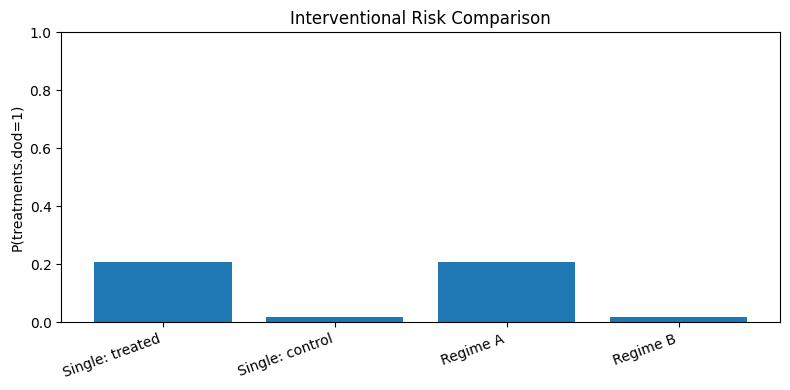

In [9]:
# Quick visual comparison
labels = ['Single: treated', 'Single: control', 'Regime A', 'Regime B']
values = [res_single['p_a'], res_single['p_b'], res_multi['p_a'], res_multi['p_b']]

fig, ax = plt.subplots()
ax.bar(labels, values)
ax.set_ylabel(f'P({OUTCOME}={OUTCOME_POSITIVE})')
ax.set_title('Interventional Risk Comparison')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Margin Status Effects And Benefit Of Preoperative Radiotherapy

This section evaluates:

1. **Effect of different margin states** via $P(Y \mid do(M=m), X=x)$ for each margin value.
2. **Benefit of preoperative RT conditional on margin state** via
   $\Delta_{RT}(m) = P(Y \mid do(RT=1, M=m), X=x) - P(Y \mid do(RT=0, M=m), X=x)$.

Negative $\Delta_{RT}(m)$ indicates lower risk under preoperative RT (benefit).

In [10]:
MARGIN_VAR = 'treatments.pathologist_margin_judgement'
RT_VAR_CANDIDATES = [
    'treatments.radiotherapy_preoperative',
    'treatments.any_radiotherapy',
]

# Clinical mapping provided by user.
MARGIN_LABELS = {0: 'R1', 1: 'R2'}

if MARGIN_VAR not in model.nodes():
    raise RuntimeError(f"{MARGIN_VAR} is not present in the loaded model.")

RT_VAR = next((v for v in RT_VAR_CANDIDATES if v in model.nodes()), None)
if RT_VAR is None:
    raise RuntimeError(f"None of RT candidates found in model: {RT_VAR_CANDIDATES}")

margin_states = state_names(model, MARGIN_VAR)
rt_states = state_names(model, RT_VAR)
rt_off = 0 if 0 in rt_states else rt_states[0]
rt_on = 1 if 1 in rt_states else (rt_states[-1] if len(rt_states) > 1 else rt_states[0])

print(f"Using margin variable: {MARGIN_VAR} with states {margin_states}")
print(f"Margin clinical labels: {MARGIN_LABELS}")
print(f"Using RT variable: {RT_VAR} with states {rt_states} (off={rt_off}, on={rt_on})")

rows = []
for m in margin_states:
    p_margin = p_outcome_given_do(
        model,
        outcome=OUTCOME,
        outcome_state=OUTCOME_POSITIVE,
        interventions={MARGIN_VAR: m},
        evidence=X if X else None,
    )

    p_rt_on = p_outcome_given_do(
        model,
        outcome=OUTCOME,
        outcome_state=OUTCOME_POSITIVE,
        interventions={MARGIN_VAR: m, RT_VAR: rt_on},
        evidence=X if X else None,
    )
    p_rt_off = p_outcome_given_do(
        model,
        outcome=OUTCOME,
        outcome_state=OUTCOME_POSITIVE,
        interventions={MARGIN_VAR: m, RT_VAR: rt_off},
        evidence=X if X else None,
    )

    delta_rt = p_rt_on - p_rt_off
    rr_rt = (p_rt_on / p_rt_off) if p_rt_off > 0 else np.nan

    rows.append({
        'margin_state': m,
        'margin_label': MARGIN_LABELS.get(m, str(m)),
        'P_Y_do_margin': p_margin,
        'P_Y_do_rt_on_margin': p_rt_on,
        'P_Y_do_rt_off_margin': p_rt_off,
        'delta_rt_on_minus_off': delta_rt,
        'rr_rt_on_vs_off': rr_rt,
        'rt_benefit_if_negative': -delta_rt,
    })

margin_rt_df = pd.DataFrame(rows).sort_values('margin_state').reset_index(drop=True)
margin_rt_df

Using margin variable: treatments.pathologist_margin_judgement with states [0, 1]
Margin clinical labels: {0: 'R1', 1: 'R2'}
Using RT variable: treatments.radiotherapy_preoperative with states [0, 1] (off=0, on=1)


,margin_state,margin_label,P_Y_do_margin,P_Y_do_rt_on_margin,P_Y_do_rt_off_margin,delta_rt_on_minus_off,rr_rt_on_vs_off,rt_benefit_if_negative
0,0,R1,0.043240,0.206223,0.018108,0.188116,11.388732,-0.188116
1,1,R2,0.045651,0.203286,0.022097,0.181189,9.199580,-0.181189


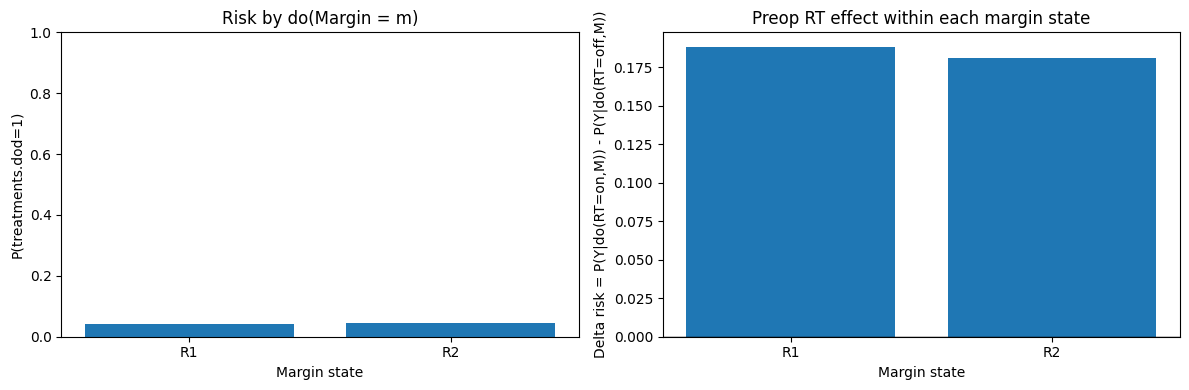


Interpretation guide: delta < 0 means RT lowers risk for that margin state.


,margin_state,margin_label,P_Y_do_margin,P_Y_do_rt_on_margin,P_Y_do_rt_off_margin,delta_rt_on_minus_off,rr_rt_on_vs_off
0,0,R1,0.043240,0.206223,0.018108,0.188116,11.388732
1,1,R2,0.045651,0.203286,0.022097,0.181189,9.199580


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_labels = margin_rt_df['margin_label'] if 'margin_label' in margin_rt_df.columns else margin_rt_df['margin_state'].astype(str)

# Panel 1: risk by margin intervention only
axes[0].bar(x_labels, margin_rt_df['P_Y_do_margin'])
axes[0].set_title('Risk by do(Margin = m)')
axes[0].set_ylabel(f"P({OUTCOME}={OUTCOME_POSITIVE})")
axes[0].set_xlabel('Margin state')
axes[0].set_ylim(0, 1)

# Panel 2: RT benefit by margin state (negative is beneficial on risk scale)
axes[1].bar(x_labels, margin_rt_df['delta_rt_on_minus_off'])
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Preop RT effect within each margin state')
axes[1].set_ylabel('Delta risk = P(Y|do(RT=on,M)) - P(Y|do(RT=off,M))')
axes[1].set_xlabel('Margin state')

plt.tight_layout()
plt.show()

summary_cols = [
    'margin_state',
    'margin_label',
    'P_Y_do_margin',
    'P_Y_do_rt_on_margin',
    'P_Y_do_rt_off_margin',
    'delta_rt_on_minus_off',
    'rr_rt_on_vs_off',
]
print('\nInterpretation guide: delta < 0 means RT lowers risk for that margin state.')
margin_rt_df[summary_cols]

## IPTW Adjustment For Confounding By Indication

The previous do-intervention contrasts can be biased if preoperative RT is more often assigned to higher-risk patients.

This section applies IPTW from `dags/estimate_effect.py` to estimate the RT effect on `treatments.dod` after balancing baseline confounders.

Notes:
- Margin status (`treatments.pathologist_margin_judgement`) is post-treatment in this pipeline, so it is not used as a confounder.
- ATE is reported as treated minus control; negative values indicate lower risk under RT.

In [12]:
# Import IPTW utilities and data-prep helpers from project scripts.
dags_path = PROJECT_ROOT / 'dags'
if str(dags_path) not in sys.path:
    sys.path.insert(0, str(dags_path))

from estimate_effect import estimate_ate_with_iptw
from fit_bn import _load_config, _load_data_from_mongodb, _apply_feature_selection, _validate_and_clean_data

In [13]:
config_path = PROJECT_ROOT / 'dags' / 'config' / 'surgery_rt_dag.yaml'
config = _load_config(str(config_path))

RT_IPTW_VAR = 'treatments.radiotherapy_preoperative'
OUTCOME_IPTW_VAR = 'treatments.any_metastasis'

# Use baseline confounders only (avoid post-treatment variables).
BASELINE_CONFOUNDERS = [
    'general.age',
    'tumor_characteristics.initial_size',
    'tumor_characteristics.extremity_tumor',
    'tumor_characteristics.anatomic_region_grouping',
]


def prepare_analysis_data(df_raw):
    cleaned = _validate_and_clean_data(
        df_raw.copy(),
        dag_nodes=list(model.nodes()),
        binning_config=config.get('binning', {}),
    )
    return cleaned[0] if isinstance(cleaned, tuple) else cleaned

# Start from held-out EM test set if available.
if (PROJECT_ROOT / 'dags' / 'test_data_em.pkl').exists():
    raw_data = pd.read_pickle(PROJECT_ROOT / 'dags' / 'test_data_em.pkl')
else:
    raw_data = _load_data_from_mongodb(config)
    if config.get('features'):
        raw_data = _apply_feature_selection(raw_data, config)

analysis_data = prepare_analysis_data(raw_data)

# If test split has no treatment variation, fallback to full MongoDB sample.
treat_counts = analysis_data[RT_IPTW_VAR].value_counts(dropna=False).to_dict()
print('Initial RT counts:', treat_counts)
if analysis_data[RT_IPTW_VAR].nunique(dropna=True) < 2:
    print('No treated/control overlap in current sample -> reloading full MongoDB data.')
    raw_full = _load_data_from_mongodb(config)
    if config.get('features'):
        raw_full = _apply_feature_selection(raw_full, config)
    analysis_data = prepare_analysis_data(raw_full)
    print('Fallback RT counts:', analysis_data[RT_IPTW_VAR].value_counts(dropna=False).to_dict())

iptw_overall_result = estimate_ate_with_iptw(
    model=model,
    treatment=RT_IPTW_VAR,
    outcome=OUTCOME_IPTW_VAR,
    data=analysis_data,
    confounders=[c for c in BASELINE_CONFOUNDERS if c in analysis_data.columns],
    stabilized=True,
    truncate=0.05,
    min_ps=0.0,
    n_bootstrap=300,
    hard_evidence=(X if X else None),
    virtual_evidence=None,
)

iptw_overall_df = pd.DataFrame([
    {
        'treatment': RT_IPTW_VAR,
        'outcome': OUTCOME_IPTW_VAR,
        'ate_treated_minus_control': iptw_overall_result.get('ate'),
        'ci_lower': iptw_overall_result.get('ci_lower'),
        'ci_upper': iptw_overall_result.get('ci_upper'),
        'p_value': iptw_overall_result.get('p_value'),
    }
])
iptw_overall_df


Validating and cleaning data...
Initial data shape: (48, 9)
Data columns: ['tumor_characteristics.initial_size', 'treatments.any_local_recurrence', 'treatments.any_metastasis', 'treatments.dod', 'tumor_characteristics.anatomic_region_grouping', 'treatments.radiotherapy_preoperative', 'tumor_characteristics.extremity_tumor', 'treatments.pathologist_margin_judgement', 'general.age']
DAG nodes: ['tumor_characteristics.initial_size', 'treatments.any_local_recurrence', 'treatments.any_metastasis', 'treatments.dod', 'tumor_characteristics.anatomic_region_grouping', 'treatments.radiotherapy_preoperative', 'tumor_characteristics.extremity_tumor', 'treatments.pathologist_margin_judgement', 'general.age']

Column data types:
  tumor_characteristics.initial_size: dtype=float64, unique=2, null=7
  treatments.any_local_recurrence: dtype=float64, unique=2, null=0
  treatments.any_metastasis: dtype=float64, unique=2, null=0
  treatments.dod: dtype=float64, unique=1, null=0
  tumor_characteristics.an

,treatment,outcome,ate_treated_minus_control,ci_lower,ci_upper,p_value
0,treatments.radiotherapy_preoperative,treatments.any_metastasis,0.157495,0.006446,0.330062,0.033333


In [14]:
MARGIN_STRATA_VAR = 'treatments.pathologist_margin_judgement'
margin_states = [0, 1]

iptw_by_margin_rows = []
for m in margin_states:
    ev = dict(X) if X else {}
    ev[MARGIN_STRATA_VAR] = m

    try:
        r = estimate_ate_with_iptw(
            model=model,
            treatment=RT_IPTW_VAR,
            outcome=OUTCOME_IPTW_VAR,
            data=analysis_data,
            confounders=[c for c in BASELINE_CONFOUNDERS if c in analysis_data.columns],
            stabilized=True,
            truncate=0.05,
            min_ps=0.0,
            n_bootstrap=300,
            hard_evidence=ev,
            virtual_evidence=None,
        )

        iptw_by_margin_rows.append(
            {
                'margin_state': m,
                'margin_label': MARGIN_LABELS.get(m, str(m)) if 'MARGIN_LABELS' in globals() else str(m),
                'ate_treated_minus_control': r.get('ate'),
                'ci_lower': r.get('ci_lower'),
                'ci_upper': r.get('ci_upper'),
                'p_value': r.get('p_value'),
            }
        )
    except Exception as e:
        iptw_by_margin_rows.append(
            {
                'margin_state': m,
                'margin_label': MARGIN_LABELS.get(m, str(m)) if 'MARGIN_LABELS' in globals() else str(m),
                'ate_treated_minus_control': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan,
                'p_value': np.nan,
                'error': str(e),
            }
        )

iptw_by_margin_df = pd.DataFrame(iptw_by_margin_rows)
iptw_by_margin_df


[Binary PS for treatments.radiotherapy_preoperative] Using confounders: ['general.age', 'tumor_characteristics.initial_size', 'tumor_characteristics.extremity_tumor', 'tumor_characteristics.anatomic_region_grouping']

[Binary PS for treatments.radiotherapy_preoperative] Using confounders: ['general.age', 'tumor_characteristics.initial_size', 'tumor_characteristics.extremity_tumor', 'tumor_characteristics.anatomic_region_grouping']

[Binary PS for treatments.radiotherapy_preoperative] Using confounders: ['general.age', 'tumor_characteristics.initial_size', 'tumor_characteristics.extremity_tumor', 'tumor_characteristics.anatomic_region_grouping']

[Binary PS for treatments.radiotherapy_preoperative] Using confounders: ['general.age', 'tumor_characteristics.initial_size', 'tumor_characteristics.extremity_tumor', 'tumor_characteristics.anatomic_region_grouping']

[Binary PS for treatments.radiotherapy_preoperative] Using confounders: ['general.age', 'tumor_characteristics.initial_size', '

,margin_state,margin_label,ate_treated_minus_control,ci_lower,ci_upper,p_value
0,0,R1,0.157495,0.006446,0.330062,0.033333
1,1,R2,0.157495,0.006446,0.330062,0.033333


## Notes

- These are **model-based causal queries** under your DAG and CPDs.
- For policy comparisons in observational data with confounding by indication, complement this with IPTW analyses (see `dags/estimate_effect.py`).
- Ensure positivity and support: if a regime has near-zero probability in your data/model, estimates may be unstable.